# Phase 4 — Feature Engineering

Only features the 11 columns actually support (**no property age**, nothing invented). Two kinds of code:

* **Stateless derivations** (`add_stateless_features`) are pure row-wise and run pre-split.
* **Fitted features** (`FeatureBuilder`, encoders) learn something from data (Size clip fence, floor medians,
  train start date, city levels, locality target means). They live in the `ColumnTransformer`, **fit on train
  only**, and are re-fit inside every CV fold.

Per Phase 2, every `Size`-derived feature is computed **after** the train-fitted clipper. Feature groups are chosen
by **train-only 5-fold CV** (filtered train, Phase-3 split). Val/test are not used (`EVALUATE_TEST = False`).
Nothing is saved.

Colab: upload `House_Rent_Dataset.csv` into the working directory, then *Runtime → Run all*.

In [1]:
import time, hashlib, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.base import BaseEstimator, TransformerMixin, clone
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split, KFold, cross_validate
from sklearn.compose import ColumnTransformer, TransformedTargetRegressor
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler, TargetEncoder
from sklearn.linear_model import Ridge
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.metrics import make_scorer, mean_squared_error, mean_absolute_error, r2_score

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 60); pd.set_option("display.width", 160)
sns.set_theme(style="whitegrid")
RANDOM_STATE = 42
EVALUATE_TEST = False
TARGET = "Rent"
raw = pd.read_csv("House_Rent_Dataset.csv")
print("Raw shape:", raw.shape)

Raw shape: (4746, 12)


## 0. Phase-2 cleaning code (verbatim from `phase2_cleaning.ipynb`)

In [2]:
# ======================= PHASE-2 STATELESS RULES — COPY VERBATIM INTO PHASE 5 =======================
TEXT_COLS = ["Posted On", "Floor", "Area Type", "Area Locality", "City",
             "Furnishing Status", "Tenant Preferred", "Point of Contact"]
FLOOR_LEVEL_MAP = {"Ground": 0, "Upper Basement": -1, "Lower Basement": -2}


def rule_strip_text(df):
    df = df.copy()
    for c in TEXT_COLS:
        df[c] = df[c].astype(str).str.strip()
    df["Area Locality"] = (df["Area Locality"].str.lower()
                           .str.replace(r"[^a-z0-9]+", " ", regex=True)
                           .str.strip())
    return df


def rule_validity(df):
    ok = (df["Rent"] > 0) & (df["Size"] > 0) & (df["BHK"] >= 1) & (df["Bathroom"] >= 1)
    return df[ok]


def rule_dedup_relisted(df):
    return df.drop_duplicates(subset=[c for c in df.columns if c != "Posted On"], keep="first")


def rule_parse_floor(df):
    df = df.copy()
    parts = df["Floor"].str.split(" out of ", n=1, expand=True).reindex(columns=[0, 1])
    cur = parts[0].replace(FLOOR_LEVEL_MAP)
    df["current_floor"] = pd.to_numeric(cur, errors="coerce").astype("float64")
    df["total_floors"] = pd.to_numeric(parts[1], errors="coerce").astype("float64")
    bad = df["current_floor"] > df["total_floors"]          # NaN comparisons are False
    df.loc[bad, "total_floors"] = df.loc[bad, "current_floor"]
    return df


def rule_parse_date(df):
    df = df.copy()
    df["posted_date"] = pd.to_datetime(df["Posted On"], format="%Y-%m-%d", errors="coerce")
    return df


STATELESS_RULES = [rule_strip_text, rule_validity, rule_dedup_relisted, rule_parse_floor, rule_parse_date]


def apply_stateless_rules(df, verbose=True):
    """Apply all distribution-free rules in a fixed order. Returns (clean_df, log_df)."""
    log = []
    for rule in STATELESS_RULES:
        n_before = len(df)
        df = rule(df)
        log.append({"rule": rule.__name__, "rows_before": n_before, "rows_after": len(df),
                    "rows_removed": n_before - len(df)})
    log = pd.DataFrame(log)
    if verbose:
        print(log.to_string(index=False))
    return df.reset_index(drop=True), log
# =====================================================================================================

In [3]:
# ======================= PHASE-2 LEARNED CLEANING — COPY VERBATIM INTO PHASE 5 =======================
class LogIQRClipper(BaseEstimator, TransformerMixin):
    """Clip numeric columns to Tukey fences learned on log1p(x) of the TRAIN data.

    side: "lower", "upper" or "both". k: IQR multiplier. Fences are stored in fit; transform never
    drops rows, it only clips, so val/test can be transformed with the train-learned fences.
    """
    def __init__(self, k=1.5, side="lower"):
        self.k = k
        self.side = side

    def fit(self, X, y=None):
        L = np.log1p(np.asarray(X, dtype="float64"))
        q1, q3 = np.nanpercentile(L, 25, axis=0), np.nanpercentile(L, 75, axis=0)
        iqr = q3 - q1
        self.lower_ = np.expm1(q1 - self.k * iqr) if self.side in ("lower", "both") else np.full(L.shape[1], -np.inf)
        self.upper_ = np.expm1(q3 + self.k * iqr) if self.side in ("upper", "both") else np.full(L.shape[1], np.inf)
        self.n_features_in_ = L.shape[1]
        if hasattr(X, "columns"):
            self.feature_names_in_ = np.asarray(X.columns, dtype=object)
        return self

    def transform(self, X):
        A = np.asarray(X, dtype="float64")
        return np.clip(A, self.lower_, self.upper_)

    def get_feature_names_out(self, input_features=None):
        if input_features is not None:
            return np.asarray(input_features, dtype=object)
        return getattr(self, "feature_names_in_", np.asarray([f"x{i}" for i in range(self.n_features_in_)], dtype=object))


def train_only_far_out_mask(X_train, y_train, k=3.0):
    """Keep-mask for TRAIN rows: drop rows whose log(Rent/Size) lies beyond Tukey far-out fences (k=3)
    computed on the train rows themselves. Never call this on val/test."""
    rps = np.log(np.asarray(y_train, dtype="float64") / X_train["Size"].to_numpy(dtype="float64"))
    q1, q3 = np.percentile(rps, [25, 75]); iqr = q3 - q1
    lo, hi = q1 - k * iqr, q3 + k * iqr
    keep = (rps >= lo) & (rps <= hi)
    return keep, {"k": k, "rent_per_sqft_lower": float(np.exp(lo)), "rent_per_sqft_upper": float(np.exp(hi)),
                  "n_dropped": int((~keep).sum())}


NUM_IMPUTER = SimpleImputer(strategy="median")          # fit on X_train in Phase 5
CAT_IMPUTER = SimpleImputer(strategy="most_frequent")   # safety net (0 categorical NaNs today)
# =====================================================================================================

## 1. Stateless feature derivations + the Phase-3 split — `COPY VERBATIM INTO PHASE 5`
| Feature | Definition | Why it is stateless |
|---|---|---|
| `locality_key` | `City + " | " + Area Locality` | string concat; disambiguates the 4 locality names shared across cities |
| `posted_month`, `posted_dow` | from `posted_date` | calendar fields of the row's own date |

The split function reproduces Phase 3 exactly (q=10 bins, two-step, seed 42) and asserts the Phase-3 index hashes.

In [4]:
# ============== PHASE-4 STATELESS FEATURES + PHASE-3 SPLIT — COPY VERBATIM INTO PHASE 5 ==============
def add_stateless_features(df):
    df = df.copy()
    df["locality_key"] = df["City"] + " | " + df["Area Locality"]
    df["posted_month"] = df["posted_date"].dt.month.astype("float64")
    df["posted_dow"] = df["posted_date"].dt.dayofweek.astype("float64")
    return df


STRAT_Q = 10
EXPECTED_HASHES = {"train": "82bf32b8437a934e", "val": "55e1909c244731ec", "test": "1874e7d6b55e66dd"}


def index_hash(idx):
    return hashlib.sha256(np.sort(np.asarray(idx)).tobytes()).hexdigest()[:16]


def make_split(df):
    """70/15/15 two-step split stratified on q=10 target bins (bins for splitting ONLY, never a feature)."""
    y = df[TARGET]
    X = df.drop(columns=[TARGET])
    bins = pd.qcut(y, q=STRAT_Q, labels=False, duplicates="drop")
    X_temp, X_test, y_temp, y_test = train_test_split(X, y, test_size=0.15, random_state=RANDOM_STATE, stratify=bins)
    X_train, X_val, y_train, y_val = train_test_split(X_temp, y_temp, test_size=0.1765, random_state=RANDOM_STATE,
                                                      stratify=bins.loc[X_temp.index])
    got = {"train": index_hash(X_train.index), "val": index_hash(X_val.index), "test": index_hash(X_test.index)}
    assert got == EXPECTED_HASHES, f"split differs from Phase 3: {got}"
    return X_train, X_val, X_test, y_train, y_val, y_test
# =====================================================================================================

In [5]:
clean, _ = apply_stateless_rules(raw)
clean = add_stateless_features(clean)
X_train, X_val, X_test, y_train, y_val, y_test = make_split(clean)
keep, far_info = train_only_far_out_mask(X_train, y_train, k=3.0)
X_tr, y_tr = X_train.loc[keep], y_train.loc[keep]
print("Split OK (hashes match Phase 3):", len(X_train), len(X_val), len(X_test))
print("Train-only far-out filter:", far_info, "→ train used for CV:", X_tr.shape)
del X_val, X_test, y_val, y_test          # not needed in Phase 4 — keeps them structurally out of reach

               rule  rows_before  rows_after  rows_removed
    rule_strip_text         4746        4746             0
      rule_validity         4746        4746             0
rule_dedup_relisted         4746        4737             9
   rule_parse_floor         4737        4737             0
    rule_parse_date         4737        4737             0
Split OK (hashes match Phase 3): 3315 711 711
Train-only far-out filter: {'k': 3.0, 'rent_per_sqft_lower': 0.4369066666666667, 'rent_per_sqft_upper': 1271.5657552083335, 'n_dropped': 2} → train used for CV: (3313, 17)


## 2. Fitted feature builder (Size-derived features come *after* the clipper)

`FeatureBuilder(groups=...)` learns from the data passed to `fit` (train or CV fold-train only) and emits
named numeric columns. Groups:

| group | columns | learned in `fit` |
|---|---|---|
| `base` (always) | `BHK`, `Bathroom` | — |
| `size_raw` | `size` (clipped) | Size clip fence |
| `log` | `log_size`, `log_bhk`, `log_bath` | Size clip fence (log of clipped size) |
| `floor` | `current_floor`, `total_floors` (imputed, total ≥ current), `floor_ratio`, `is_basement`, `log_total_floors` | floor medians |
| `ratios` | `size_per_bhk`, `log_size_per_bhk`, `bath_per_bhk` | — (from clipped size) |
| `date` | `days_since_start`, `posted_month` | train start date |
| `dow` | `posted_dow` | — |
| `city_x_size` | `log_size × 1[City=c]` per city | city levels |

In [6]:
# ======================= PHASE-4 FITTED FEATURE BUILDER — COPY VERBATIM INTO PHASE 5 =======================
FEATURE_GROUPS = ("log", "floor", "city_x_size")   # chosen in Phase 4 (see decisions)
LOCALITY_ENCODING = "target"
FB_INPUT_COLS = ["BHK", "Bathroom", "Size", "current_floor", "total_floors", "posted_date",
                 "posted_month", "posted_dow", "City"]


class FeatureBuilder(BaseEstimator, TransformerMixin):
    """Numeric feature construction whose parameters are learned on the fit data (train / CV fold-train only)."""
    def __init__(self, groups=FEATURE_GROUPS, clip_k=1.5):
        self.groups = groups
        self.clip_k = clip_k

    def fit(self, X, y=None):
        X = pd.DataFrame(X, columns=FB_INPUT_COLS) if not hasattr(X, "columns") else X
        self.clipper_ = LogIQRClipper(k=self.clip_k, side="lower").fit(X[["Size"]])
        self.floor_imputer_ = SimpleImputer(strategy="median").fit(X[["current_floor", "total_floors"]])
        self.start_date_ = pd.to_datetime(X["posted_date"]).min()
        self.cities_ = sorted(X["City"].unique())
        self.feature_names_out_ = np.asarray(list(self._build(X.head(2)).columns), dtype=object)
        self.n_features_in_ = X.shape[1]
        return self

    def _build(self, X):
        g = set(self.groups)
        out = pd.DataFrame(index=X.index)
        size = self.clipper_.transform(X[["Size"]]).ravel()
        bhk, bath = X["BHK"].to_numpy("float64"), X["Bathroom"].to_numpy("float64")
        out["BHK"], out["Bathroom"] = bhk, bath
        if "size_raw" in g:
            out["size"] = size
        if "log" in g:
            out["log_size"], out["log_bhk"], out["log_bath"] = np.log1p(size), np.log1p(bhk), np.log1p(bath)
        if "floor" in g:
            fl = self.floor_imputer_.transform(X[["current_floor", "total_floors"]])
            cur, tot = fl[:, 0], np.maximum(fl[:, 1], fl[:, 0])
            out["current_floor"], out["total_floors"] = cur, tot
            out["floor_ratio"] = np.clip(cur, 0, None) / np.maximum(tot, 1)
            out["is_basement"] = (cur < 0).astype("float64")
            out["log_total_floors"] = np.log1p(tot)
        if "ratios" in g:
            out["size_per_bhk"] = size / bhk
            out["log_size_per_bhk"] = np.log1p(size / bhk)
            out["bath_per_bhk"] = bath / bhk
        if "date" in g:
            out["days_since_start"] = (pd.to_datetime(X["posted_date"]) - self.start_date_).dt.days.to_numpy("float64")
            out["posted_month"] = X["posted_month"].to_numpy("float64")
        if "dow" in g:
            out["posted_dow"] = X["posted_dow"].to_numpy("float64")
        if "city_x_size" in g:
            ls = np.log1p(size)
            for c in self.cities_:
                out[f"logsize_x_{c}"] = ls * (X["City"].to_numpy() == c)
        return out

    def transform(self, X):
        X = pd.DataFrame(X, columns=FB_INPUT_COLS) if not hasattr(X, "columns") else X
        return self._build(X).to_numpy("float64")

    def get_feature_names_out(self, input_features=None):
        return self.feature_names_out_


CAT_COLS = ["City", "Furnishing Status", "Area Type", "Tenant Preferred", "Point of Contact"]


def build_preprocessor(groups=FEATURE_GROUPS, locality=LOCALITY_ENCODING):
    """Unfitted ColumnTransformer. locality ∈ {"target", "count", None}. Fit on X_train ONLY."""
    parts = [("num", FeatureBuilder(groups=groups), FB_INPUT_COLS),
             ("cat", OneHotEncoder(handle_unknown="infrequent_if_exist", min_frequency=10,
                                   sparse_output=False), CAT_COLS)]
    if locality == "target":
        # cross-fitted inside fit_transform (no row sees its own target); smoothing learned ("auto")
        parts.append(("loc", TargetEncoder(target_type="continuous", smooth="auto", cv=5,
                                           shuffle=True, random_state=RANDOM_STATE), ["locality_key"]))
    elif locality == "count":
        parts.append(("loc", LocalityCountEncoder(), ["locality_key"]))
    return ColumnTransformer(parts, remainder="drop", verbose_feature_names_out=True)


class LocalityCountEncoder(BaseEstimator, TransformerMixin):
    """log1p(number of TRAIN rows sharing the locality); unseen → 0. Uses no target."""
    def fit(self, X, y=None):
        s = pd.Series(np.asarray(X).ravel())
        self.counts_ = s.value_counts().to_dict()
        self.n_features_in_ = 1
        return self

    def transform(self, X):
        s = pd.Series(np.asarray(X).ravel())
        return np.log1p(s.map(self.counts_).fillna(0).to_numpy("float64")).reshape(-1, 1)

    def get_feature_names_out(self, input_features=None):
        return np.asarray(["locality_count_log"], dtype=object)
# =====================================================================================================

In [7]:
# Sanity: fit on train only, inspect output
pre = build_preprocessor().fit(X_tr, np.log1p(y_tr))
Z = pre.transform(X_tr)
names = pre.get_feature_names_out()
print("Features:", len(names)); print(list(names))
print("Any NaN/inf:", bool(~np.isfinite(Z).all()))
display(pd.DataFrame(Z, columns=names).describe().T[["mean", "std", "min", "max"]].round(3))

Features: 34
['num__BHK', 'num__Bathroom', 'num__log_size', 'num__log_bhk', 'num__log_bath', 'num__current_floor', 'num__total_floors', 'num__floor_ratio', 'num__is_basement', 'num__log_total_floors', 'num__logsize_x_Bangalore', 'num__logsize_x_Chennai', 'num__logsize_x_Delhi', 'num__logsize_x_Hyderabad', 'num__logsize_x_Kolkata', 'num__logsize_x_Mumbai', 'cat__City_Bangalore', 'cat__City_Chennai', 'cat__City_Delhi', 'cat__City_Hyderabad', 'cat__City_Kolkata', 'cat__City_Mumbai', 'cat__Furnishing Status_Furnished', 'cat__Furnishing Status_Semi-Furnished', 'cat__Furnishing Status_Unfurnished', 'cat__Area Type_Carpet Area', 'cat__Area Type_Super Area', 'cat__Tenant Preferred_Bachelors', 'cat__Tenant Preferred_Bachelors/Family', 'cat__Tenant Preferred_Family', 'cat__Point of Contact_Contact Agent', 'cat__Point of Contact_Contact Owner', 'cat__Point of Contact_infrequent_sklearn', 'loc__locality_key']
Any NaN/inf: False


,mean,std,min,max
num__BHK,2.092,0.836,1.000,6.000
num__Bathroom,1.964,0.884,1.000,10.000
num__log_size,6.697,0.623,5.143,8.987
num__log_bhk,1.093,0.271,0.693,1.946
num__log_bath,1.046,0.281,0.693,2.398
num__current_floor,3.466,5.896,-2.000,76.000
num__total_floors,6.970,9.505,1.000,85.000
num__floor_ratio,0.459,0.316,0.000,1.000
num__is_basement,0.006,0.079,0.000,1.000
num__log_total_floors,1.727,0.732,0.693,4.454


## 3. Evidence: which groups earn their place? (train-only 5-fold CV, log1p target, metrics in ₹)
Two model families: **Ridge** (scaled, linear, sensitive to feature form) and **HistGB** (trees, insensitive to
monotone transforms). Every transform, including the target encoder, is re-fit inside each fold.

In [8]:
cv = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
scoring = {"rmse": make_scorer(lambda a, p: np.sqrt(mean_squared_error(a, p)), greater_is_better=False),
           "mae": make_scorer(mean_absolute_error, greater_is_better=False),
           "r2": make_scorer(r2_score),
           "rmsle": make_scorer(lambda a, p: np.sqrt(mean_squared_error(np.log1p(a), np.log1p(np.clip(p, 0, None)))),
                                greater_is_better=False)}

def make_model(kind, pre):
    steps = [("prep", pre)]
    steps += [("scale", StandardScaler()), ("model", Ridge(alpha=1.0))] if kind == "Ridge" else \
             [("model", HistGradientBoostingRegressor(random_state=RANDOM_STATE))]
    return TransformedTargetRegressor(Pipeline(steps), func=np.log1p, inverse_func=np.expm1)

def run_cv(kind, groups, locality):
    s = cross_validate(make_model(kind, build_preprocessor(groups, locality)), X_tr, y_tr, cv=cv, scoring=scoring)
    return {"CV RMSE (₹)": -s["test_rmse"].mean(), "RMSE sd": s["test_rmse"].std(), "CV MAE (₹)": -s["test_mae"].mean(),
            "CV R²": s["test_r2"].mean(), "CV RMSLE": -s["test_rmsle"].mean()}

FMT = {"CV RMSE (₹)": 0, "RMSE sd": 0, "CV MAE (₹)": 0, "CV R²": 4, "CV RMSLE": 4}

### 3a. Additive ablation (each row adds one group to the previous)

In [9]:
R = ("size_raw",)
steps = [("A0 base + size + OHE cats", R,                                                None),
         ("A1 + log",                  R + ("log",),                                     None),
         ("A2 + floor",                R + ("log", "floor"),                             None),
         ("A3 + ratios",               R + ("log", "floor", "ratios"),                   None),
         ("A4 + date",                 R + ("log", "floor", "ratios", "date"),           None),
         ("A5 + locality (target enc)", R + ("log", "floor", "ratios", "date"),          "target"),
         ("A6 + city×log_size",        R + ("log", "floor", "ratios", "date", "city_x_size"), "target")]
t0 = time.perf_counter()
add = pd.DataFrame([{"model": k, "step": n, **run_cv(k, g, l)} for k in ("Ridge", "HistGB") for n, g, l in steps]
                   ).set_index(["model", "step"])
display(add.round(FMT)); print(f"({time.perf_counter() - t0:.0f}s)")

CV RMSE (₹)   RMSE sd  CV MAE (₹)     CV R²  CV RMSLE
model  step                                                                             
Ridge  A0 base + size + OHE cats       33651.0    5936.0     11589.0    0.6520    0.3890
       A1 + log                        32333.0    6655.0     11359.0    0.6825    0.3877
       A2 + floor                      31407.0    7110.0     11205.0    0.7023    0.3842
       A3 + ratios                    479043.0  894641.0     28608.0 -426.1863    0.3928
       A4 + date                      491952.0  920413.0     29114.0 -450.7957    0.3929
       A5 + locality (target enc)     249096.0  438081.0     18910.0 -104.2574    0.3717
       A6 + city×log_size             127137.0  189699.0     14075.0  -20.5166    0.3659
HistGB A0 base + size + OHE cats       29500.0    7127.0     10682.0    0.7384    0.3801
       A1 + log                        29500.0    7127.0     10682.0    0.7384    0.3801
       A2 + floor                      29750.0    7202.0     10720.0    0.7340    0.3757
       A3 + ratios                     29330.0    6786.0     10575.0    0.7419    0.3732
       A4 + date                       29635.0    6790.0     10522.0    0.7364    0.3752
       A5 + locality (target enc)      28530.0    7922.0     10047.0    0.7551    0.3595
       A6 + city×log_size              28102.0    7294.0      9940.0    0.7615    0.3602

(23s)


### 3b. Leave-one-group-out from the full set (marginal value *in context*) + locality alternatives

In [10]:
FULL = ("size_raw", "log", "floor", "ratios", "date", "city_x_size")
variants = [("FULL (target-enc locality)", FULL, "target")]
variants += [(f"FULL − {g}", tuple(x for x in FULL if x != g), "target") for g in FULL]
variants += [("FULL, locality = count enc", FULL, "count"), ("FULL, no locality", FULL, None),
             ("FULL + dow", FULL + ("dow",), "target")]
t0 = time.perf_counter()
loo = pd.DataFrame([{"model": k, "variant": n, **run_cv(k, g, l)} for k in ("Ridge", "HistGB") for n, g, l in variants]
                   ).set_index(["model", "variant"])
display(loo.round(FMT)); print(f"({time.perf_counter() - t0:.0f}s)")

CV RMSE (₹)    RMSE sd  CV MAE (₹)      CV R²  CV RMSLE
model  variant                                                                            
Ridge  FULL (target-enc locality)     127137.0   189699.0     14075.0   -20.5166    0.3659
       FULL − size_raw                866678.0  1673441.0     42950.0 -1472.5034    0.3775
       FULL − log                     424112.0   780609.0     25861.0  -326.3370    0.3732
       FULL − floor                   113661.0   162859.0     13595.0   -15.2444    0.3675
       FULL − ratios                   32178.0     7888.0     10260.0     0.6725    0.3602
       FULL − date                    123963.0   183192.0     13942.0   -19.1784    0.3657
       FULL − city_x_size             249096.0   438081.0     18910.0  -104.2574    0.3717
       FULL, locality = count enc     325904.0   585257.0     22547.0  -185.0654    0.3873
       FULL, no locality              272046.0   478772.0     20582.0  -124.6944    0.3869
       FULL + dow                     127640.0   190496.0     14094.0   -20.6948    0.3660
HistGB FULL (target-enc locality)      28102.0     7294.0      9940.0     0.7615    0.3602
       FULL − size_raw                 28099.0     7288.0      9938.0     0.7616    0.3602
       FULL − log                      28102.0     7294.0      9940.0     0.7615    0.3602
       FULL − floor                    28237.0     7463.0     10127.0     0.7599    0.3635
       FULL − ratios                   27992.0     7140.0      9951.0     0.7638    0.3602
       FULL − date                     27607.0     6842.0      9883.0     0.7705    0.3567
       FULL − city_x_size              28530.0     7922.0     10047.0     0.7551    0.3595
       FULL, locality = count enc      29423.0     6236.0     10369.0     0.7390    0.3710
       FULL, no locality               29616.0     6001.0     10563.0     0.7349    0.3752
       FULL + dow                      28064.0     7424.0      9897.0     0.7626    0.3593

(38s)


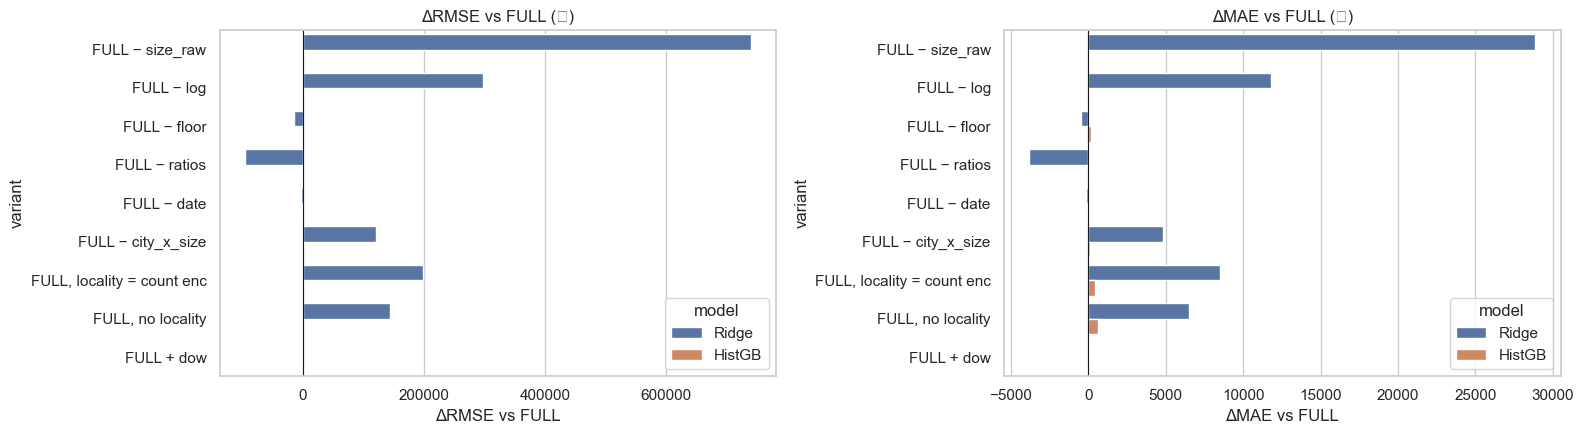

In [11]:
# Visual: ΔCV-RMSE and ΔMAE vs FULL (positive = removing/altering the group HURTS → group is useful)
d = loo.copy()
for k in ("Ridge", "HistGB"):
    base = d.loc[(k, "FULL (target-enc locality)")]
    d.loc[k, "ΔRMSE vs FULL"] = (d.loc[k, "CV RMSE (₹)"] - base["CV RMSE (₹)"]).values
    d.loc[k, "ΔMAE vs FULL"] = (d.loc[k, "CV MAE (₹)"] - base["CV MAE (₹)"]).values
dd = d.drop(index="FULL (target-enc locality)", level=1).reset_index()
fig, ax = plt.subplots(1, 2, figsize=(16, 4.5))
for a, m in zip(ax, ["ΔRMSE vs FULL", "ΔMAE vs FULL"]):
    sns.barplot(data=dd, y="variant", x=m, hue="model", ax=a); a.axvline(0, color="k", lw=.8); a.set_title(m + " (₹)")
plt.tight_layout(); plt.show()

### 3c. Why does Ridge explode when `ratios` is added? (look-only diagnostic on train)

In [12]:
fb = FeatureBuilder(groups=FULL).fit(X_tr)
Zf = pd.DataFrame(fb.transform(X_tr), columns=fb.get_feature_names_out(), index=X_tr.index)
z = (Zf - Zf.mean()) / Zf.std()
print("Largest |z| per feature (train):"); print(z.abs().max().sort_values(ascending=False).head(6).round(1).to_string())
worst = z.abs().max(axis=1).idxmax()
print("\nRow driving the extremes:"); display(X_tr.loc[[worst], ["BHK", "Bathroom", "Size", "City", "Area Locality"]].assign(Rent=y_tr[worst]))
from sklearn.model_selection import cross_val_predict
oof = cross_val_predict(make_model("Ridge", build_preprocessor(R + ("log", "floor", "ratios"), None)), X_tr, y_tr, cv=cv)
print(f"Ridge(+ratios) out-of-fold prediction for that row: ₹{oof[X_tr.index.get_loc(worst)]:,.0f} (actual ₹{y_tr[worst]:,.0f})")
print("Raw ratios put it 28–35 SD out → linear extrapolation in log space → expm1 explodes.")
print("For a linear model log(size/bhk) = log(size) − log(bhk) is already spanned by the `log` group, so ratios add nothing.")

Largest |z| per feature (train):
size_per_bhk     34.6
bath_per_bhk     28.5
is_basement      12.5
current_floor    12.3
size             11.1
Bathroom          9.1

Row driving the extremes:


,BHK,Bathroom,Size,City,Area Locality,Rent
4176,1,10,8000,Hyderabad,beeramguda ramachandra puram nh 9,200000


Ridge(+ratios) out-of-fold prediction for that row: ₹58,601,881 (actual ₹200,000)
Raw ratios put it 28–35 SD out → linear extrapolation in log space → expm1 explodes.
For a linear model log(size/bhk) = log(size) − log(bhk) is already spanned by the `log` group, so ratios add nothing.


### 3d. Final selection: drop the groups that hurt in context (`ratios`, `date`, `dow`) and test raw `size`

In [13]:
final_variants = [("A0 baseline (Phase-3 style)", ("size_raw",), None),
                  ("FINAL = log + floor + city×size + locality TE", FEATURE_GROUPS, "target"),
                  ("FINAL + size_raw", FEATURE_GROUPS + ("size_raw",), "target"),
                  ("FINAL − floor", tuple(g for g in FEATURE_GROUPS if g != "floor"), "target"),
                  ("FINAL − city×size", tuple(g for g in FEATURE_GROUPS if g != "city_x_size"), "target"),
                  ("FINAL, no locality", FEATURE_GROUPS, None)]
fin = pd.DataFrame([{"model": k, "variant": n, **run_cv(k, g, l)} for k in ("Ridge", "HistGB") for n, g, l in final_variants]
                   ).set_index(["model", "variant"])
display(fin.round(FMT))

CV RMSE (₹)  RMSE sd  CV MAE (₹)   CV R²  CV RMSLE
model  variant                                                                                          
Ridge  A0 baseline (Phase-3 style)                        33651.0   5936.0     11589.0  0.6520    0.3890
       FINAL = log + floor + city×size + locality TE      30141.0   6589.0     10691.0  0.7270    0.3719
       FINAL + size_raw                                   32239.0   8150.0     10254.0  0.6701    0.3601
       FINAL − floor                                      29779.0   6568.0     10605.0  0.7335    0.3730
       FINAL − city×size                                  30236.0   7839.0     10801.0  0.7262    0.3756
       FINAL, no locality                                 31749.0   6704.0     11427.0  0.6968    0.3921
HistGB A0 baseline (Phase-3 style)                        29500.0   7127.0     10682.0  0.7384    0.3801
       FINAL = log + floor + city×size + locality TE      27936.0   7584.0      9886.0  0.7642    0.3586
       FINAL + size_raw                                   27939.0   7589.0      9887.0  0.7641    0.3586
       FINAL − floor                                      28239.0   7523.0     10089.0  0.7595    0.3629
       FINAL − city×size                                  28130.0   7643.0     10014.0  0.7626    0.3595
       FINAL, no locality                                 29412.0   6281.0     10504.0  0.7380    0.3719

## 4. Phase-5 design check: target-encoding *once* vs *per fold*
Phase 5 fits the preprocessor once on train and saves encoded matrices. Model notebooks then run CV on those
fixed matrices. For a **target encoder** that means fold-train rows carry encodings computed with targets that
include the fold-val rows, which is a leak *inside CV* (val/test are unaffected; they use the full-train encoder).
How large is that optimism? Compare **per-fold refit** (correct) with **encode once on all train, then CV**
(what a saved-matrix design would do).

In [14]:
def once_then_cv(kind):
    pre = build_preprocessor(FEATURE_GROUPS, "target")
    Z = pre.fit_transform(X_tr, np.log1p(y_tr))           # cross-fitted on ALL train rows, frozen
    model = Pipeline(([("scale", StandardScaler()), ("model", Ridge(alpha=1.0))] if kind == "Ridge"
                      else [("model", HistGradientBoostingRegressor(random_state=RANDOM_STATE))]))
    s = cross_validate(TransformedTargetRegressor(model, func=np.log1p, inverse_func=np.expm1), Z, y_tr, cv=cv, scoring=scoring)
    return {"CV RMSE (₹)": -s["test_rmse"].mean(), "RMSE sd": s["test_rmse"].std(), "CV MAE (₹)": -s["test_mae"].mean(),
            "CV R²": s["test_r2"].mean(), "CV RMSLE": -s["test_rmsle"].mean()}

rows = []
for k in ("Ridge", "HistGB"):
    rows.append({"model": k, "design": "per-fold refit (correct)", **fin.loc[(k, "FINAL = log + floor + city×size + locality TE")].to_dict()})
    rows.append({"model": k, "design": "encode once, then CV (saved-matrix)", **once_then_cv(k)})
    rows.append({"model": k, "design": "no locality (no target info)", **fin.loc[(k, "FINAL, no locality")].to_dict()})
leak = pd.DataFrame(rows).set_index(["model", "design"])
display(leak.round(FMT))

CV RMSE (₹)  RMSE sd  CV MAE (₹)   CV R²  CV RMSLE
model  design                                                                                 
Ridge  per-fold refit (correct)                 30141.0   6589.0     10691.0  0.7270    0.3719
       encode once, then CV (saved-matrix)      29992.0   6947.0     10668.0  0.7299    0.3721
       no locality (no target info)             31749.0   6704.0     11427.0  0.6968    0.3921
HistGB per-fold refit (correct)                 27936.0   7584.0      9886.0  0.7642    0.3586
       encode once, then CV (saved-matrix)      28056.0   7113.0      9929.0  0.7635    0.3577
       no locality (no target info)             29412.0   6281.0     10504.0  0.7380    0.3719


## 5. Phase-4 decisions

### Final feature set: `FEATURE_GROUPS = ("log", "floor", "city_x_size")`, `LOCALITY_ENCODING = "target"` → **34 columns**
| Block | Columns | Fitted on train |
|---|---|---|
| counts | `BHK`, `Bathroom` | — |
| `log` | `log_size` (of **clipped** Size), `log_bhk`, `log_bath` | Size clip fence |
| `floor` | `current_floor`, `total_floors`, `floor_ratio`, `is_basement`, `log_total_floors` | floor medians (4 NaN totals) |
| `city_x_size` | `logsize_x_<City>` × 6 | city levels |
| one-hot | City, Furnishing, Area Type, Tenant Preferred, Point of Contact (`min_frequency=10` → "Contact Builder" goes to the infrequent bucket; "Built Area" (2 rows) lands in val/test only, where it is encoded as all zeros) | categories |
| locality | `TargetEncoder` on `City | Area Locality`, cross-fitted, `smooth="auto"`, fit on **log1p(y_train)** | locality means |

**Gain over the Phase-3 baseline (train CV, ₹):** Ridge RMSE 33.7k → **30.1k**, MAE 11.6k → **10.7k**, R² 0.652 → **0.727**. HistGB RMSE 29.5k → **27.9k**, MAE 10.7k → **9.9k**, R² 0.738 → **0.764**.

### Group-by-group evidence
| Group | Decision | Why |
|---|---|---|
| `log` | **keep** | Ridge improves from 33.7k to 32.3k; trees are unaffected (monotone transform). |
| `floor` | **keep** | HistGB gets worse without it (RMSE 27.9k → 28.2k, MAE 9.9k → 10.1k). For Ridge it is about neutral (RMSE −1%, RMSLE +0.3%). |
| `city_x_size` | **keep** | Price per sqft differs by city. Removing it hurts both models (HistGB MAE 9.89k → 10.01k; Ridge RMSLE 0.372 → 0.376). |
| Locality target encoding | **keep** | The biggest single gain. Without it, HistGB RMSE rises from 27.9k to 29.4k and Ridge from 30.1k to 31.7k. The **count encoding** alternative is worse than target encoding for both models. |
| `ratios` (`size_per_bhk`, `bath_per_bhk`) | **drop** | Raw ratios put one row (1 BHK / 10 bath / 8,000 sqft, ₹2L) **28–35 SD** out, and Ridge then predicts **₹5.9 crore** for it. For a linear model they duplicate what the `log` group already spans; for HistGB, dropping them gives a slightly *better* RMSE. |
| `date` (`days_since_start`, `month`) | **drop** | Dropping it *improves* both models (HistGB 28.1k → 27.6k). The weak Phase-1 trend does not survive once the other features are in. |
| `dow` | **drop** | No gain. |
| raw `size` | **drop** (keep only `log_size`) | It makes Ridge RMSE worse (30.1k → 32.2k) because predictions for large homes blow up when converted back from log scale. MAE does improve slightly (10.7k → 10.3k), but one form per quantity keeps the shared matrix safe for linear models. HistGB is identical either way. |
| property age | **not created** | Posting date ≠ build date. |

The raw `Floor`, `Posted On`, `posted_date` and `Area Locality` strings are **dropped** by the ColumnTransformer (`remainder="drop"`). They are replaced by the parsed or encoded features above.

### Leakage review
* The only target-derived feature is the locality encoding. It sits **inside** the train-fitted ColumnTransformer and is cross-fitted, so no row sees its own rent. The stratification bins are not a feature.
* **Phase-5 "encode once, save matrices" check:** CV on saved matrices vs a per-fold refit differs by **−0.5% (Ridge) / +0.4% (HistGB)** RMSE, with no systematic optimism. That is because sklearn's `TargetEncoder.fit_transform` already cross-fits the encoding. Val/test always use the full-train encoder, so they are clean either way.

### Effects on Phase 5 (need your sign-off on items 2 and 3)
1. The verbatim cells (Phase-2 rules and learned cleaning, Phase-4 stateless features, split, and `FeatureBuilder`/`build_preprocessor`) are the complete preparation code.
2. **Saved-matrix CV:** `CLAUDE.md` says CV re-fits transforms per fold. With the locality encoder frozen in saved matrices, Phase 6–8 CV can't refit it. The measured effect is ≤0.5%. **Recommendation:** accept and document this. Alternatively, Phase 5 could *also* save the cleaned pre-encoding frames, so Phase 7/8 tuning can refit the encoder per fold.
3. **Pickling:** `FeatureBuilder` and `LogIQRClipper` are notebook-defined classes, so a plain `joblib.load` of a bundle holding the fitted preprocessor would fail in the model notebooks. **Recommendation:** store `preprocessor` in the bundle as **cloudpickle bytes**. The bundle then loads anywhere, and the preprocessor can be restored when needed.
